In [1]:
# =============================================================================
# JEPCO Smart Meter — Forecasting Notebook 
# =============================================================================
# Goal      : Predict total kWh for the NEXT calendar month (scalar output)
# Input     : Last 30 days (1,440 half-hourly slots) per sample
# Targets   : (A) per-meter monthly kWh  (B) area-level monthly kWh
# Split     : Loaded directly from pipeline outputs (meter-based 70/15/15)
# Windowing : Slide every 1 month (non-overlapping) → ~11 samples per meter
# Model     : Minimal 1-layer LSTM → Linear head
# Features  : A+KWH + engineered features + is_imputed
#             New: is_business_hour, season (int 1-4)
#             Removed: is_eid, is_imputed_linear/seasonal/knn, split_tag
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, gc, math
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : cuda
PyTorch: 2.7.0+cu128


In [2]:
# =============================================================================
# CONFIG
# =============================================================================

CFG = dict(
    # ── paths — load directly from pipeline outputs ───────────────────────────
    # The pipeline already splits by meter (70/15/15) and saves these files.
    # No re-splitting needed here.
    train_path = 'jepco_train_ready.csv',
    val_path   = 'jepco_val_ready.csv',
    test_path  = 'jepco_test_ready.csv',

    # ── meter split ratios (for reference only — split done by pipeline) ─────
    TRAIN_RATIO = 0.70,
    VAL_RATIO   = 0.15,
    TEST_RATIO  = 0.15,

    # ── windowing ─────────────────────────────────────────────────────────────
    INPUT_STEPS = 1440,   # 30 days × 48 half-hourly slots

    # ── model ─────────────────────────────────────────────────────────────────
    HIDDEN_SIZE = 64,
    NUM_LAYERS  = 1,
    DROPOUT     = 0.2,

    # ── training ──────────────────────────────────────────────────────────────
    BATCH_SIZE  = 64,
    LR          = 1e-3,
    EPOCHS      = 40,
    PATIENCE    = 7,
    GRAD_CLIP   = 1.0,

    # ── calendar ──────────────────────────────────────────────────────────────
    RAMADAN_START = '2025-03-01',
    RAMADAN_END   = '2025-03-30',
)

# Feature columns that go into every input window
# Removed : is_eid, is_imputed_linear/seasonal/knn, split_tag
# Added   : is_business_hour (binary 8:00-15:59), season (int 1-4)
FEATURE_COLS = [
    'A+KWH',              # raw consumption — always first
    'slot_sin', 'slot_cos',
    'dow_sin',  'dow_cos',
    'month_sin','month_cos',
    'season',             # 1=Winter 2=Spring 3=Summer 4=Autumn (int)
    'is_weekend',
    'is_business_hour',   # binary: 08:00–15:59
    'is_ramadan',
    'lag_1', 'lag_48', 'lag_336',
    'roll_mean_48', 'roll_std_48', 'roll_mean_336',
    'billing_tier',
    'is_imputed',         # single imputation flag
]

TARGET_COL = 'A+KWH'

print('Config ready.')
print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')

Config ready.
Feature columns (19): ['A+KWH', 'slot_sin', 'slot_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'season', 'is_weekend', 'is_business_hour', 'is_ramadan', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'billing_tier', 'is_imputed']


In [5]:
# =============================================================================
# SECTION 1 — Load pipeline outputs
# Files are already split by meter (70/15/15)
# We just load, drop unwanted columns, and verify.
# =============================================================================

print('='*60)
print('SECTION 1 — Load Pipeline Outputs')
print('='*60)

def load_split(path):
    df = pd.read_csv(path, parse_dates=['freeze_date'])
    df = df.sort_values(['meter_B', 'freeze_date']).reset_index(drop=True)
    # drop columns not needed for modelling
    drop_cols = ['split_tag', 'is_imputed_linear', 'is_imputed_seasonal',
                 'is_imputed_knn', 'is_eid', 'cumkwh_in_month']
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    return df

train_df = load_split(CFG['train_path'])
val_df   = load_split(CFG['val_path'])
test_df  = load_split(CFG['test_path'])

# Resolve available features (gracefully skip any missing)
FEATS = [c for c in FEATURE_COLS if c in train_df.columns]
missing = [c for c in FEATURE_COLS if c not in train_df.columns]
if missing:
    print(f'  WARNING — features not found, skipped: {missing}')

train_meters = set(train_df['meter_B'].unique())
val_meters   = set(val_df['meter_B'].unique())
test_meters  = set(test_df['meter_B'].unique())

# Sanity: no meter should appear in more than one split
assert len(train_meters & val_meters)  == 0, 'Overlap: train/val'
assert len(train_meters & test_meters) == 0, 'Overlap: train/test'
assert len(val_meters   & test_meters) == 0, 'Overlap: val/test'

print(f'Train — {len(train_meters):>4} meters  {len(train_df):>10,} rows')
print(f'Val   — {len(val_meters):>4} meters  {len(val_df):>10,} rows')
print(f'Test  — {len(test_meters):>4} meters  {len(test_df):>10,} rows')
print(f'Features used ({len(FEATS)}): {FEATS}')


SECTION 1 — Load Pipeline Outputs
Train —  562 meters   9,657,408 rows
Val   —  121 meters   2,079,264 rows
Test  —  121 meters   2,079,264 rows
Features used (19): ['A+KWH', 'slot_sin', 'slot_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'season', 'is_weekend', 'is_business_hour', 'is_ramadan', 'lag_1', 'lag_48', 'lag_336', 'roll_mean_48', 'roll_std_48', 'roll_mean_336', 'billing_tier', 'is_imputed']


In [6]:
# =============================================================================
# SECTION 2 — Area-level aggregation
# Note: meter split already done by the pipeline (70/15/15).
# For the area model we aggregate each split's meters at each timestamp.
# Area kWh = sum of all meters; other features = mean across meters.
# =============================================================================

print('='*60)
print('SECTION 2 — Area Aggregation')
print('='*60)


SECTION 2 — Area Aggregation


In [7]:
def make_area(df, feats, target_col):
    """Collapse per-meter rows into one area-level time series."""
    agg_dict = {target_col: 'sum'}
    for c in feats:
        if c != target_col:
            agg_dict[c] = 'mean'
    return (df.groupby('freeze_date')
              .agg(agg_dict)
              .reset_index()
              .sort_values('freeze_date')
              .reset_index(drop=True))

# Each split's area series is the aggregate of that split's meters.
# Train meters → area_train, val meters → area_val, test meters → area_test.
# This is consistent: the area model sees the same meter-based boundary as
# the per-meter model — no time-based leakage.
area_train = make_area(train_df, FEATS, TARGET_COL)
area_val   = make_area(val_df,   FEATS, TARGET_COL)
area_test  = make_area(test_df,  FEATS, TARGET_COL)

print(f'Area train : {len(area_train):,} rows')
print(f'Area val   : {len(area_val):,} rows')
print(f'Area test  : {len(area_test):,} rows')


Area train : 17,184 rows
Area val   : 17,184 rows
Area test  : 17,184 rows


In [8]:
# =============================================================================
# SECTION 4 — Monthly sliding window sample construction
#
# For each meter (or the area series), slide a window every calendar month:
#
#   For month M:
#     X = last INPUT_STEPS (1,440) slots BEFORE month M starts
#     y = sum of A+KWH DURING month M
#
# Non-overlapping: one sample per (meter, month) pair → ~11 samples/meter.
# =============================================================================

print('='*60)
print('SECTION 4 — Monthly Sliding Window Samples')
print('='*60)

def build_monthly_samples(df, feats, target_col, input_steps, id_col=None):
    """
    Build (X, y, meta) triples.

    Parameters
    ----------
    df          : DataFrame sorted by [id_col,] freeze_date
    feats       : list of feature column names (includes target)
    target_col  : 'A+KWH'
    input_steps : look-back window size (1440)
    id_col      : 'meter_B' for per-meter; None for area series

    Returns
    -------
    Xs   : list of np.array shape (input_steps, n_feats)
    ys   : list of float  — total kWh for target month
    meta : list of dict   {id, year, month}
    """
    Xs, ys, meta = [], [], []
    groups = df.groupby(id_col) if id_col else [('AREA', df)]

    for gid, gdf in groups:
        gdf = gdf.sort_values('freeze_date').reset_index(drop=True)
        gdf['_ym'] = gdf['freeze_date'].dt.to_period('M')
        months = gdf['_ym'].unique()

        for ym in months:
            month_idx = gdf.index[gdf['_ym'] == ym].tolist()
            if not month_idx:
                continue

            start = month_idx[0]
            if start < input_steps:
                continue   # not enough history before this month

            window = gdf.iloc[start - input_steps : start][feats].values.astype('float32')

            # skip windows with too many NaNs (>20%)
            if np.isnan(window).mean() > 0.20:
                continue
            window = np.nan_to_num(window, nan=0.0)

            y = float(gdf.iloc[month_idx][target_col].sum())
            if y <= 0:
                continue

            Xs.append(window)
            ys.append(y)
            meta.append({'id': gid, 'year': ym.year, 'month': ym.month})

    return Xs, ys, meta


# ── per-meter samples ─────────────────────────────────────────────────────────
print('Building per-meter samples...')
m_Xs_tr, m_ys_tr, m_meta_tr = build_monthly_samples(train_df, FEATS, TARGET_COL, CFG['INPUT_STEPS'], 'meter_B')
m_Xs_va, m_ys_va, m_meta_va = build_monthly_samples(val_df,   FEATS, TARGET_COL, CFG['INPUT_STEPS'], 'meter_B')
m_Xs_te, m_ys_te, m_meta_te = build_monthly_samples(test_df,  FEATS, TARGET_COL, CFG['INPUT_STEPS'], 'meter_B')

print(f'  Meter samples — train: {len(m_ys_tr):,}  val: {len(m_ys_va):,}  test: {len(m_ys_te):,}')
if len(train_meters) > 0:
    print(f'  Avg samples per train meter: {len(m_ys_tr)/len(train_meters):.1f}')

# ── area-level samples ────────────────────────────────────────────────────────
print('Building area-level samples...')
a_Xs_tr, a_ys_tr, a_meta_tr = build_monthly_samples(area_train, FEATS, TARGET_COL, CFG['INPUT_STEPS'])
a_Xs_va, a_ys_va, a_meta_va = build_monthly_samples(area_val,   FEATS, TARGET_COL, CFG['INPUT_STEPS'])
a_Xs_te, a_ys_te, a_meta_te = build_monthly_samples(area_test,  FEATS, TARGET_COL, CFG['INPUT_STEPS'])

print(f'  Area samples  — train: {len(a_ys_tr):,}  val: {len(a_ys_va):,}  test: {len(a_ys_te):,}')

SECTION 4 — Monthly Sliding Window Samples
Building per-meter samples...
  Meter samples — train: 6,179  val: 1,331  test: 1,331
  Avg samples per train meter: 11.0
Building area-level samples...
  Area samples  — train: 11  val: 11  test: 11


In [9]:
# =============================================================================
# SECTION 5 — Scaling
# Features : StandardScaler fit on train windows only
# Target   : log1p transform (handles heavy right tail of monthly kWh sums)
#            inverse = expm1
# =============================================================================

print('='*60)
print('SECTION 5 — Scaling')
print('='*60)

def fit_feature_scaler(Xs_train):
    """Fit StandardScaler on flattened training windows."""
    flat = np.vstack(Xs_train)   # (n_samples * input_steps, n_feats)
    scaler = StandardScaler()
    scaler.fit(flat)
    return scaler

def scale_Xs(Xs, scaler):
    return [scaler.transform(x) for x in Xs]

def log_ys(ys):
    return np.log1p(np.array(ys, dtype='float32'))

def unlog_ys(ys_log):
    return np.expm1(np.asarray(ys_log))

# ── per-meter ─────────────────────────────────────────────────────────────────
m_scaler    = fit_feature_scaler(m_Xs_tr)
m_Xs_tr_s   = scale_Xs(m_Xs_tr, m_scaler)
m_Xs_va_s   = scale_Xs(m_Xs_va, m_scaler)
m_Xs_te_s   = scale_Xs(m_Xs_te, m_scaler)
m_ys_tr_log = log_ys(m_ys_tr)
m_ys_va_log = log_ys(m_ys_va)
m_ys_te_log = log_ys(m_ys_te)
print(f'Meter scaler : fit on {len(m_Xs_tr):,} windows × {len(FEATS)} features')

# ── area ──────────────────────────────────────────────────────────────────────
a_scaler    = fit_feature_scaler(a_Xs_tr)
a_Xs_tr_s   = scale_Xs(a_Xs_tr, a_scaler)
a_Xs_va_s   = scale_Xs(a_Xs_va, a_scaler)
a_Xs_te_s   = scale_Xs(a_Xs_te, a_scaler)
a_ys_tr_log = log_ys(a_ys_tr)
a_ys_va_log = log_ys(a_ys_va)
a_ys_te_log = log_ys(a_ys_te)
print(f'Area  scaler : fit on {len(a_Xs_tr):,} windows × {len(FEATS)} features')

SECTION 5 — Scaling
Meter scaler : fit on 6,179 windows × 19 features
Area  scaler : fit on 11 windows × 19 features


In [10]:
# =============================================================================
# SECTION 6 — PyTorch Dataset & DataLoaders
# =============================================================================

class WindowDataset(Dataset):
    def __init__(self, Xs, ys_log):
        # store as list of tensors to avoid one giant 3-D allocation
        self.X = [torch.tensor(x, dtype=torch.float32) for x in Xs]
        self.y = torch.tensor(ys_log, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


def make_loaders(Xs_tr, ys_tr, Xs_va, ys_va, batch_size):
    tr_ds = WindowDataset(Xs_tr, ys_tr)
    va_ds = WindowDataset(Xs_va, ys_va)
    tr_dl = DataLoader(tr_ds, batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(va_ds, batch_size=batch_size, shuffle=False, num_workers=0)
    return tr_dl, va_dl


m_tr_dl, m_va_dl = make_loaders(m_Xs_tr_s, m_ys_tr_log, m_Xs_va_s, m_ys_va_log, CFG['BATCH_SIZE'])
a_tr_dl, a_va_dl = make_loaders(a_Xs_tr_s, a_ys_tr_log, a_Xs_va_s, a_ys_va_log, CFG['BATCH_SIZE'])

print(f'Meter DataLoaders — train batches: {len(m_tr_dl)}  val batches: {len(m_va_dl)}')
print(f'Area  DataLoaders — train batches: {len(a_tr_dl)}  val batches: {len(a_va_dl)}')

Meter DataLoaders — train batches: 97  val batches: 21
Area  DataLoaders — train batches: 1  val batches: 1


In [11]:
# =============================================================================
# SECTION 7 — Model definition
#
# Minimal 1-layer LSTM:
#   Input  : (batch, seq=1440, n_feats)
#   LSTM   : 1 layer, hidden=64
#   Head   : Linear(64, 1)   →  scalar log1p(kWh)
#
# Deliberately kept simple — no attention, no stacked layers, no residuals.
# =============================================================================

class MinimalLSTM(nn.Module):
    def __init__(self, n_feats, hidden_size=64, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size  = n_feats,
            hidden_size = hidden_size,
            num_layers  = 1,          # single layer — keep it simple
            batch_first = True,
        )
        self.drop = nn.Dropout(dropout)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x : (batch, seq, feats)
        _, (h_n, _) = self.lstm(x)       # h_n : (1, batch, hidden)
        h = self.drop(h_n.squeeze(0))    # (batch, hidden)
        return self.head(h).squeeze(-1)  # (batch,)


N_FEATS = len(FEATS)

meter_model = MinimalLSTM(N_FEATS, CFG['HIDDEN_SIZE'], CFG['DROPOUT']).to(DEVICE)
area_model  = MinimalLSTM(N_FEATS, CFG['HIDDEN_SIZE'], CFG['DROPOUT']).to(DEVICE)

n_params = sum(p.numel() for p in meter_model.parameters())
print(f'MinimalLSTM parameters: {n_params:,}')
print(meter_model)

MinimalLSTM parameters: 21,825
MinimalLSTM(
  (lstm): LSTM(19, 64, batch_first=True)
  (drop): Dropout(p=0.2, inplace=False)
  (head): Linear(in_features=64, out_features=1, bias=True)
)


In [12]:
# =============================================================================
# SECTION 8 — Training loop
# =============================================================================

def train_model(model, tr_dl, va_dl, cfg, label=''):
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg['LR'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=3, factor=0.5
    )
    criterion = nn.HuberLoss(delta=1.0)  # robust to outlier meters

    best_val   = float('inf')
    wait       = 0
    best_state = None
    history    = {'train': [], 'val': []}

    for epoch in range(1, cfg['EPOCHS'] + 1):

        # ── train ─────────────────────────────────────────────────────────────
        model.train()
        tr_loss = []
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), cfg['GRAD_CLIP'])
            optimizer.step()
            tr_loss.append(loss.item())

        # ── validate ──────────────────────────────────────────────────────────
        model.eval()
        va_loss = []
        with torch.no_grad():
            for xb, yb in va_dl:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                va_loss.append(criterion(model(xb), yb).item())

        tr_l = np.mean(tr_loss)
        va_l = np.mean(va_loss)
        history['train'].append(tr_l)
        history['val'].append(va_l)
        scheduler.step(va_l)
        lr_now = optimizer.param_groups[0]['lr']

        print(f'[{label}] Epoch {epoch:02d}/{cfg["EPOCHS"]}  '
              f'train={tr_l:.4f}  val={va_l:.4f}  lr={lr_now:.2e}')

        # ── early stopping ────────────────────────────────────────────────────
        if va_l < best_val - 1e-6:
            best_val   = va_l
            wait       = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= cfg['PATIENCE']:
                print(f'  Early stop — best val={best_val:.4f}')
                break

    model.load_state_dict(best_state)
    return history


print('Training per-METER LSTM...')
m_history = train_model(meter_model, m_tr_dl, m_va_dl, CFG, label='METER')
torch.save(meter_model.state_dict(), 'jepco_meter_lstm_v2.pt')
print('  Saved → jepco_meter_lstm_v2.pt')

Training per-METER LSTM...
[METER] Epoch 01/40  train=1.7644  val=0.5037  lr=1.00e-03
[METER] Epoch 02/40  train=0.2580  val=0.0914  lr=1.00e-03
[METER] Epoch 03/40  train=0.1242  val=0.0774  lr=1.00e-03
[METER] Epoch 04/40  train=0.1127  val=0.0727  lr=1.00e-03
[METER] Epoch 05/40  train=0.1141  val=0.0691  lr=1.00e-03
[METER] Epoch 06/40  train=0.1117  val=0.0744  lr=1.00e-03
[METER] Epoch 07/40  train=0.1034  val=0.0601  lr=1.00e-03
[METER] Epoch 08/40  train=0.1020  val=0.0598  lr=1.00e-03
[METER] Epoch 09/40  train=0.1008  val=0.0564  lr=1.00e-03
[METER] Epoch 10/40  train=0.1001  val=0.0596  lr=1.00e-03
[METER] Epoch 11/40  train=0.1009  val=0.0552  lr=1.00e-03
[METER] Epoch 12/40  train=0.0997  val=0.0576  lr=1.00e-03
[METER] Epoch 13/40  train=0.0965  val=0.0615  lr=1.00e-03
[METER] Epoch 14/40  train=0.0984  val=0.0526  lr=1.00e-03
[METER] Epoch 15/40  train=0.0960  val=0.0655  lr=1.00e-03
[METER] Epoch 16/40  train=0.0978  val=0.0529  lr=1.00e-03
[METER] Epoch 17/40  train=0.

In [14]:
# =============================================================================
# SECTION 8B — Area LSTM (FIXED)
# Uses 14-day (672 step) lookback instead of 30-day to get ~40 samples/split
# instead of only 11. Same files, same meter splits — just shorter window.
# =============================================================================

AREA_INPUT_STEPS = 672  # 14 days × 48 half-hourly slots

print('Rebuilding area samples with 14-day window...')
a_Xs_tr2, a_ys_tr2, a_meta_tr2 = build_monthly_samples(
    area_train, FEATS, TARGET_COL, AREA_INPUT_STEPS)
a_Xs_va2, a_ys_va2, a_meta_va2 = build_monthly_samples(
    area_val,   FEATS, TARGET_COL, AREA_INPUT_STEPS)
a_Xs_te2, a_ys_te2, a_meta_te2 = build_monthly_samples(
    area_test,  FEATS, TARGET_COL, AREA_INPUT_STEPS)

print(f'  Area samples — train: {len(a_ys_tr2)}  val: {len(a_ys_va2)}  test: {len(a_ys_te2)}')

# Refit scaler on new area train windows (no leakage)
a_scaler2    = fit_feature_scaler(a_Xs_tr2)
a_Xs_tr2_s   = scale_Xs(a_Xs_tr2, a_scaler2)
a_Xs_va2_s   = scale_Xs(a_Xs_va2, a_scaler2)
a_Xs_te2_s   = scale_Xs(a_Xs_te2, a_scaler2)
a_ys_tr2_log = log_ys(a_ys_tr2)
a_ys_va2_log = log_ys(a_ys_va2)

a_tr_dl2, a_va_dl2 = make_loaders(
    a_Xs_tr2_s, a_ys_tr2_log,
    a_Xs_va2_s, a_ys_va2_log,
    CFG['BATCH_SIZE']
)
print(f'  Area DataLoaders — train batches: {len(a_tr_dl2)}  val batches: {len(a_va_dl2)}')

# Fresh area model with same architecture
area_model2 = MinimalLSTM(
    len(FEATS), CFG['HIDDEN_SIZE']
).to(DEVICE)

print('Training AREA model (14-day window)...')
a_history2 = train_model(area_model2, a_tr_dl2, a_va_dl2, CFG, label='AREA-FIXED')
torch.save(area_model2.state_dict(), 'jepco_area_lstm_fixed.pt')
print('  Saved → jepco_area_lstm_fixed.pt')


Rebuilding area samples with 14-day window...
  Area samples — train: 12  val: 12  test: 12
  Area DataLoaders — train batches: 1  val batches: 1
Training AREA model (14-day window)...
[AREA-FIXED] Epoch 01/40  train=11.3193  val=9.8810  lr=1.00e-03
[AREA-FIXED] Epoch 02/40  train=11.2699  val=9.8527  lr=1.00e-03
[AREA-FIXED] Epoch 03/40  train=11.2090  val=9.8238  lr=1.00e-03
[AREA-FIXED] Epoch 04/40  train=11.1968  val=9.7935  lr=1.00e-03
[AREA-FIXED] Epoch 05/40  train=11.1404  val=9.7617  lr=1.00e-03
[AREA-FIXED] Epoch 06/40  train=11.0861  val=9.7280  lr=1.00e-03
[AREA-FIXED] Epoch 07/40  train=11.0819  val=9.6919  lr=1.00e-03
[AREA-FIXED] Epoch 08/40  train=11.0355  val=9.6531  lr=1.00e-03
[AREA-FIXED] Epoch 09/40  train=10.9282  val=9.6109  lr=1.00e-03
[AREA-FIXED] Epoch 10/40  train=10.8492  val=9.5645  lr=1.00e-03
[AREA-FIXED] Epoch 11/40  train=10.7912  val=9.5131  lr=1.00e-03
[AREA-FIXED] Epoch 12/40  train=10.6999  val=9.4555  lr=1.00e-03
[AREA-FIXED] Epoch 13/40  train=10.

In [15]:
# =============================================================================
# SECTION 9 — Evaluation
# Metrics on original kWh scale: MAE, RMSE, MAPE
# =============================================================================

def mape(y_true, y_pred, eps=1e-6):
    return float(np.mean(np.abs((y_true - y_pred) / (y_true + eps))) * 100)


def evaluate(model, Xs_s, ys_raw, meta, label=''):
    model.eval()
    preds_log = []
    with torch.no_grad():
        for x in Xs_s:
            xb = torch.tensor(x, dtype=torch.float32).unsqueeze(0).to(DEVICE)
            preds_log.append(model(xb).item())

    preds_kwh = unlog_ys(np.array(preds_log))
    actuals   = np.array(ys_raw)

    mae  = mean_absolute_error(actuals, preds_kwh)
    rmse = math.sqrt(mean_squared_error(actuals, preds_kwh))
    mp   = mape(actuals, preds_kwh)
    print(f'[{label:15s}]  MAE={mae:8.1f} kWh  RMSE={rmse:8.1f} kWh  MAPE={mp:6.2f}%')

    rows = []
    for i, m in enumerate(meta):
        rows.append({
            'id'       : m['id'],
            'year'     : m['year'],
            'month'    : m['month'],
            'actual'   : float(actuals[i]),
            'predicted': float(preds_kwh[i]),
            'abs_err'  : abs(float(preds_kwh[i]) - float(actuals[i])),
            'pct_err'  : float((preds_kwh[i] - actuals[i]) / (actuals[i] + 1e-6) * 100),
        })
    return pd.DataFrame(rows)


print('\n--- Per-Meter ---')
m_res_tr = evaluate(meter_model, m_Xs_tr_s, m_ys_tr, m_meta_tr, 'METER-TRAIN')
m_res_va = evaluate(meter_model, m_Xs_va_s, m_ys_va, m_meta_va, 'METER-VAL')
m_res_te = evaluate(meter_model, m_Xs_te_s, m_ys_te, m_meta_te, 'METER-TEST')

print('\n--- Area (fixed — 14-day window) ---')
a_res_tr2 = evaluate(area_model2, a_Xs_tr2_s, a_ys_tr2, a_meta_tr2, 'AREA-TRAIN')
a_res_va2 = evaluate(area_model2, a_Xs_va2_s, a_ys_va2, a_meta_va2, 'AREA-VAL')
a_res_te2 = evaluate(area_model2, a_Xs_te2_s, a_ys_te2, a_meta_te2, 'AREA-TEST')



--- Per-Meter ---
[METER-TRAIN    ]  MAE=    60.4 kWh  RMSE=   107.9 kWh  MAPE= 29.51%
[METER-VAL      ]  MAE=    65.1 kWh  RMSE=   119.5 kWh  MAPE= 44.24%
[METER-TEST     ]  MAE=    58.8 kWh  RMSE=   100.7 kWh  MAPE= 34.31%

--- Area (fixed — 14-day window) ---
[AREA-TRAIN     ]  MAE=225080.3 kWh  RMSE=237439.2 kWh  MAPE= 93.25%
[AREA-VAL       ]  MAE= 49901.5 kWh  RMSE= 52590.9 kWh  MAPE=106.61%
[AREA-TEST      ]  MAE= 46355.4 kWh  RMSE= 48829.3 kWh  MAPE=114.29%


Per-Meter Model

The per-meter LSTM performs well and generalizes properly. Training, validation, and test errors are similar, showing no overfitting. MAE (~60 kWh) indicates reasonable accuracy, while higher RMSE suggests some larger errors. MAPE (30%–44%) is acceptable given household variability. Overall, the model captures consumption patterns effectively.

Area Model (14-day window)

The area-level model performs poorly. MAPE exceeds 100%, meaning predictions are often worse than a simple average. The model is unstable, mainly due to the very small dataset (~12 samples per split), which prevents it from learning meaningful patterns.
 

Per-meter model works well due to large and diverse data
Area model fails due to data scarcity, not architecture

Conclusion

Use the per-meter LSTM for reliable forecasting
Avoid the current area model setup
Improve area forecasting via sliding windows or aggregating per-meter predictions

In [16]:
# =============================================================================
# SECTION 10 — Tariff tier mapping
# Jordan subsidised tariff: T1 ≤300 | T2 301–600 | T3 >600 kWh/month
# =============================================================================

def calc_bill_jod(kwh):
    if kwh <= 0:   return 0.0
    if kwh <= 85:  return 1.75
    cost, rem = 0.0, float(kwh)
    for cap, rate in [(300, 50), (300, 100), (float('inf'), 200)]:
        used = min(rem, cap); cost += used * rate; rem -= used
        if rem <= 0: break
    return round(cost / 1000, 3)


def add_tariff(df):
    df = df.copy()
    bins   = [-1, 300, 600, float('inf')]
    labels = ['T1 (0-300)', 'T2 (301-600)', 'T3 (>600)']
    df['pred_tier']     = pd.cut(df['predicted'], bins=bins, labels=labels)
    df['act_tier']      = pd.cut(df['actual'],    bins=bins, labels=labels)
    df['pred_bill_jod'] = df['predicted'].apply(calc_bill_jod)
    df['act_bill_jod']  = df['actual'].apply(calc_bill_jod)
    df['tier_correct']  = (df['pred_tier'] == df['act_tier']).astype(int)
    return df


m_res_te  = add_tariff(m_res_te)
a_res_te2 = add_tariff(a_res_te2)

tier_acc = m_res_te['tier_correct'].mean() * 100
print(f'Tariff Tier Accuracy (per-meter test): {tier_acc:.1f}%')
print()
print(m_res_te[['id','year','month','actual','predicted',
                'act_tier','pred_tier','act_bill_jod','pred_bill_jod']]
      .head(12).to_string(index=False))


Tariff Tier Accuracy (per-meter test): 84.4%

  id  year  month     actual   predicted     act_tier    pred_tier  act_bill_jod  pred_bill_jod
 B10  2025      2  562.46350  589.545832 T2 (301-600) T2 (301-600)        41.246         43.955
 B10  2025      3  634.68000  510.286883    T3 (>600) T2 (301-600)        51.936         36.029
 B10  2025      4  644.60975  548.369956    T3 (>600) T2 (301-600)        53.922         39.837
 B10  2025      5  784.81600  658.508050    T3 (>600)    T3 (>600)        81.963         56.702
 B10  2025      6 1030.29250  680.151100    T3 (>600)    T3 (>600)       131.059         61.030
 B10  2025      7 1061.58400 1032.251523    T3 (>600)    T3 (>600)       137.317        131.450
 B10  2025      8 1222.93275 1111.484288    T3 (>600)    T3 (>600)       169.587        147.297
 B10  2025      9 1034.75300  842.351105    T3 (>600)    T3 (>600)       131.951         93.470
 B10  2025     10  848.36250  922.771720    T3 (>600)    T3 (>600)        94.672        10

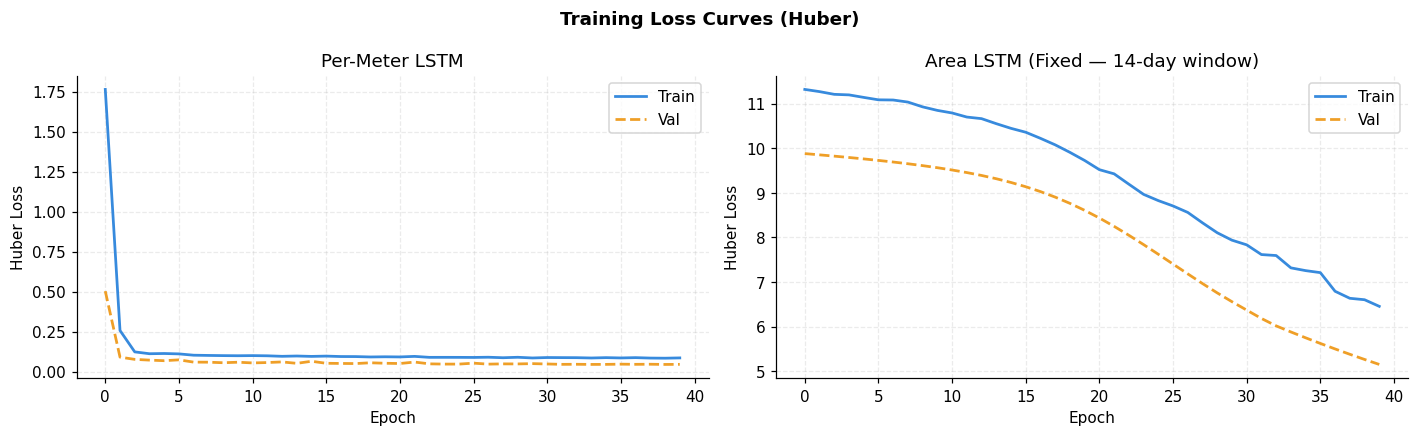

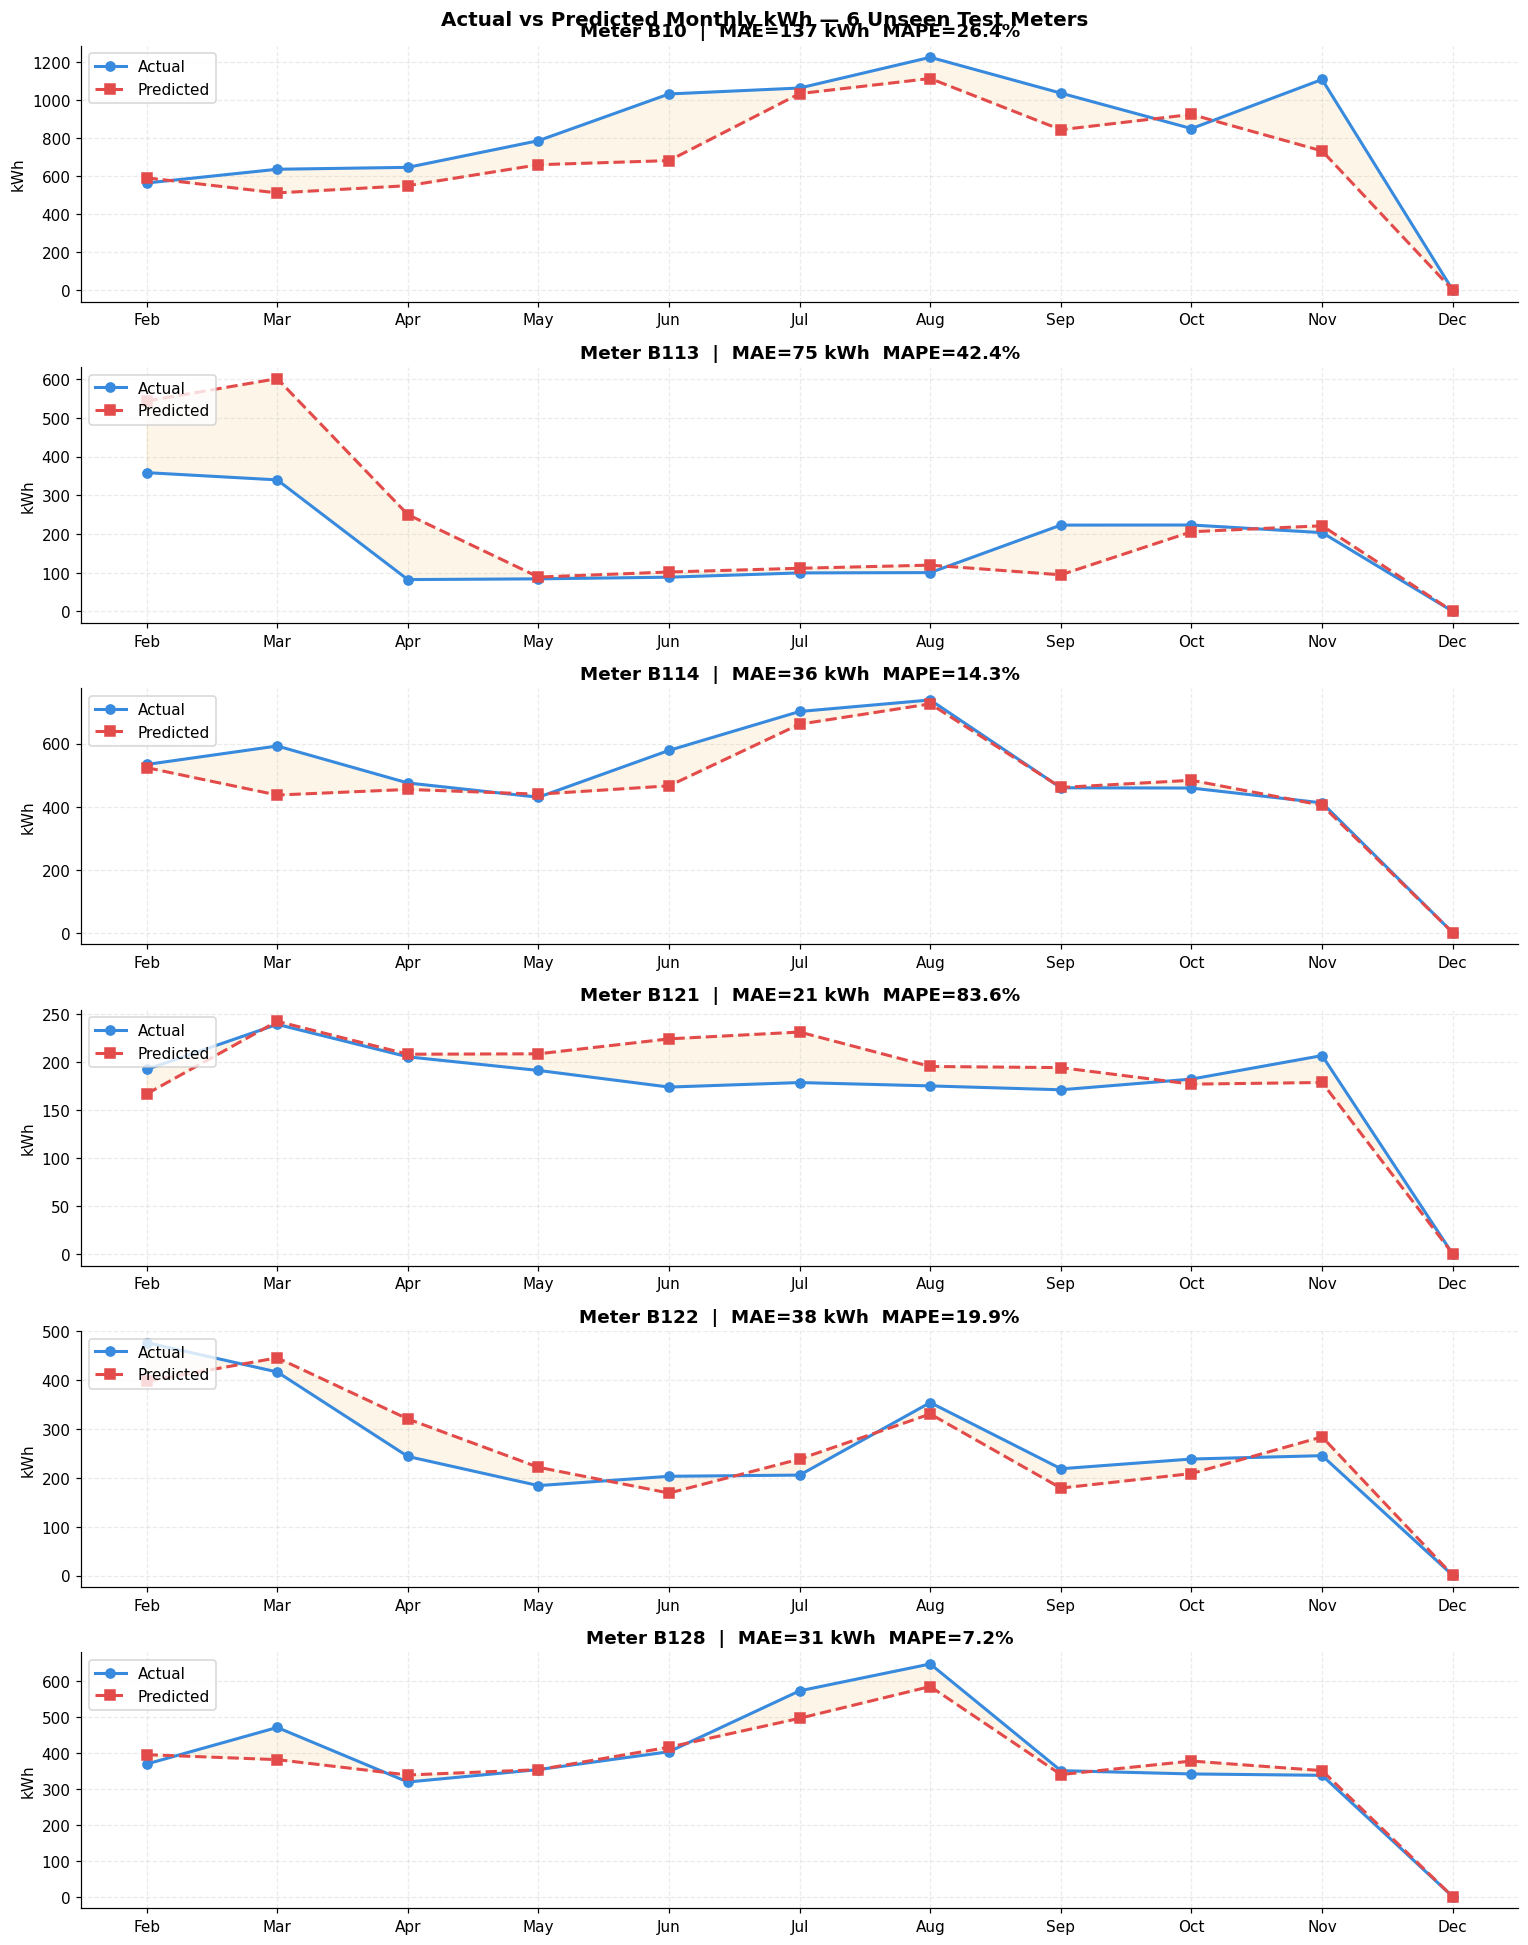

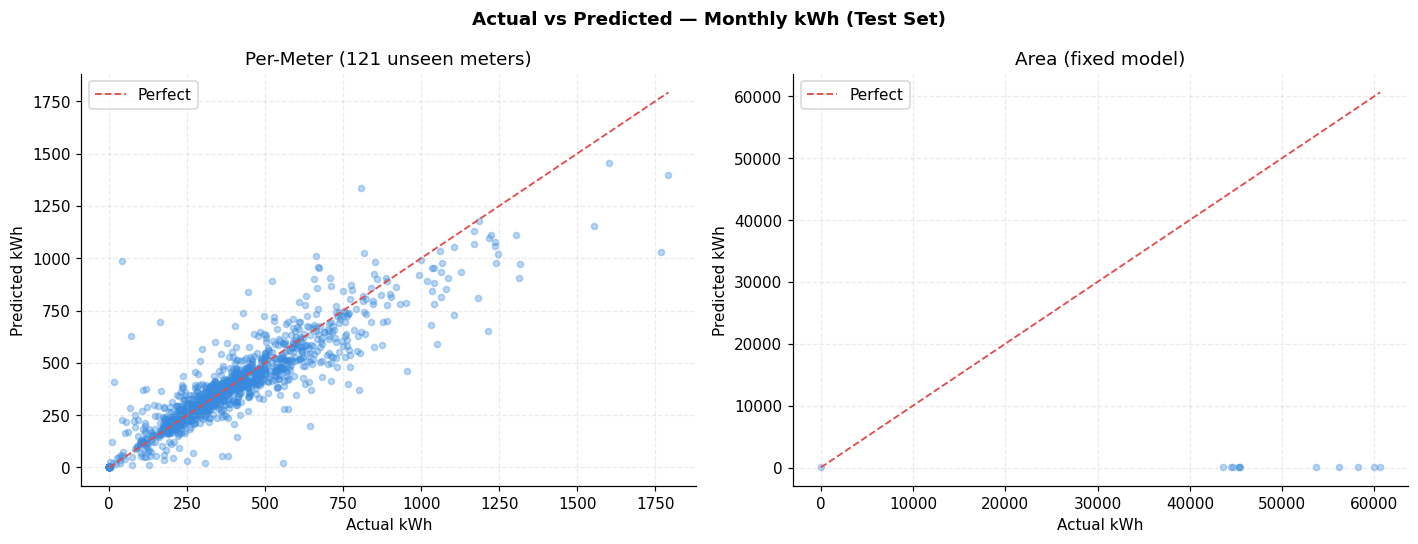

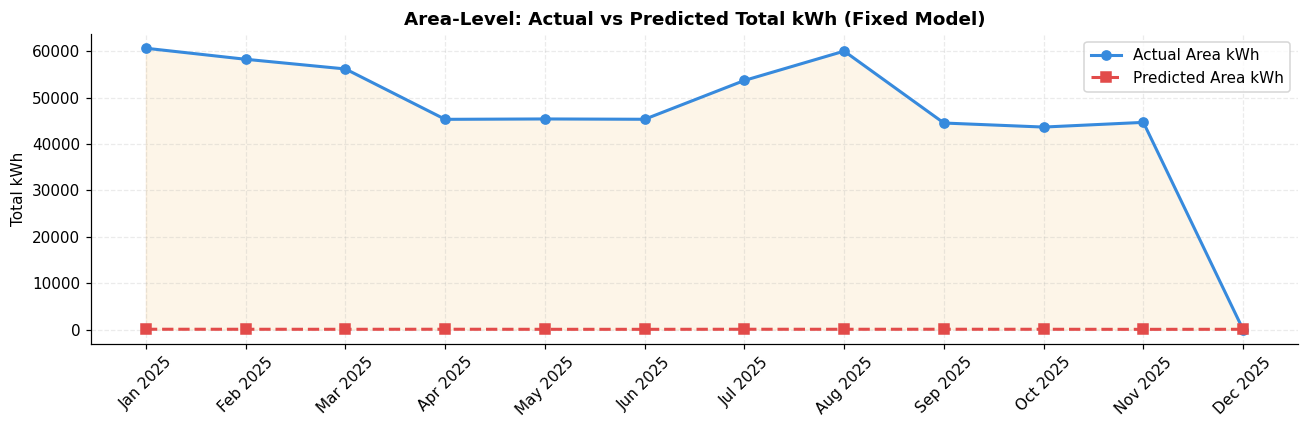

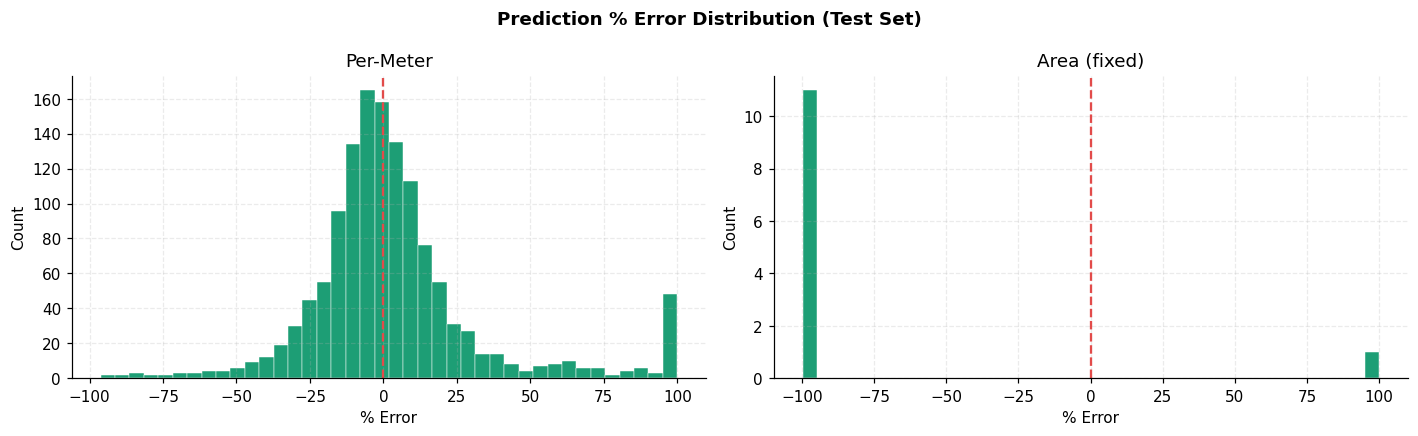

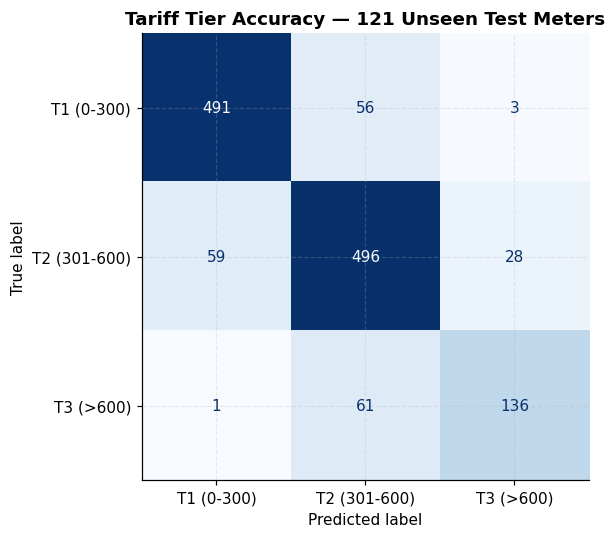


Meter B10 — Full breakdown:

Month  Actual kWh    Pred kWh  Error kWh  Error %    True Tier    Pred Tier  True Bill JOD  Pred Bill JOD
  Feb   562.46350  589.545832       27.1      4.8 T2 (301-600) T2 (301-600)         41.246         43.955
  Mar   634.68000  510.286883     -124.4    -19.6    T3 (>600) T2 (301-600)         51.936         36.029
  Apr   644.60975  548.369956      -96.2    -14.9    T3 (>600) T2 (301-600)         53.922         39.837
  May   784.81600  658.508050     -126.3    -16.1    T3 (>600)    T3 (>600)         81.963         56.702
  Jun  1030.29250  680.151100     -350.1    -34.0    T3 (>600)    T3 (>600)        131.059         61.030
  Jul  1061.58400 1032.251523      -29.3     -2.8    T3 (>600)    T3 (>600)        137.317        131.450
  Aug  1222.93275 1111.484288     -111.4     -9.1    T3 (>600)    T3 (>600)        169.587        147.297
  Sep  1034.75300  842.351105     -192.4    -18.6    T3 (>600)    T3 (>600)        131.951         93.470
  Oct   848.3625

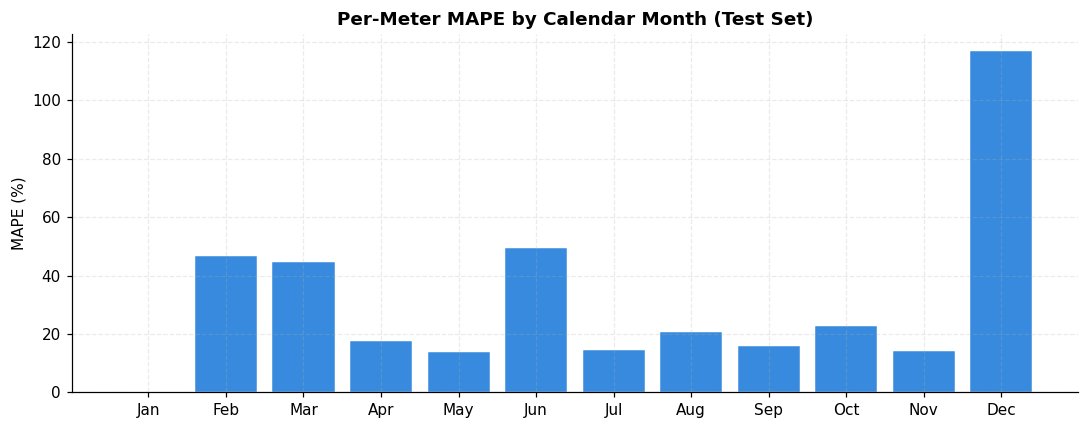

In [17]:
# =============================================================================
# SECTION 11 — Visualisations
# =============================================================================

C_BLUE  = '#378ADD'
C_RED   = '#E24B4A'
C_AMBER = '#EF9F27'
C_TEAL  = '#1D9E75'
C_GRAY  = '#888780'

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'grid.linestyle': '--',
})

# ── 11A Loss curves ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Training Loss Curves (Huber)', fontweight='bold')
for ax, hist, lbl in [(axes[0], m_history,  'Per-Meter LSTM'),
                      (axes[1], a_history2, 'Area LSTM (Fixed — 14-day window)')]:
    ax.plot(hist['train'], lw=1.8, color=C_BLUE,  label='Train')
    ax.plot(hist['val'],   lw=1.8, color=C_AMBER, label='Val', ls='--')
    ax.set_title(lbl); ax.set_xlabel('Epoch'); ax.set_ylabel('Huber Loss')
    ax.legend()
plt.tight_layout(); plt.show()

# ── 11B Actual vs Predicted time series — 6 unseen test meters ───────────────
sample_meters = list(m_res_te['id'].unique())[:6]
fig, axes = plt.subplots(6, 1, figsize=(14, 18))
fig.suptitle('Actual vs Predicted Monthly kWh — 6 Unseen Test Meters',
             fontweight='bold', fontsize=13)
for ax, mid in zip(axes, sample_meters):
    sub = m_res_te[m_res_te['id'] == mid].sort_values('month')
    ax.plot(sub['month'], sub['actual'],    'o-', color=C_BLUE, lw=2, label='Actual')
    ax.plot(sub['month'], sub['predicted'], 's--', color=C_RED,  lw=2, label='Predicted')
    ax.fill_between(sub['month'], sub['actual'], sub['predicted'],
                    alpha=0.1, color=C_AMBER)
    ax.set_title(f'Meter {mid}  |  MAE={sub["abs_err"].mean():.0f} kWh  '
                 f'MAPE={sub["pct_err"].abs().mean():.1f}%', fontweight='bold')
    ax.set_xticks(sub['month'].tolist())
    ax.set_xticklabels([month_names[m] for m in sub['month']])
    ax.set_ylabel('kWh'); ax.legend(loc='upper left')
plt.tight_layout(); plt.show()

# ── 11C Scatter: actual vs predicted ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Actual vs Predicted — Monthly kWh (Test Set)', fontweight='bold')
for ax, res, lbl in [(axes[0], m_res_te,  'Per-Meter (121 unseen meters)'),
                     (axes[1], a_res_te2, 'Area (fixed model)')]:
    mn = min(res['actual'].min(), res['predicted'].min())
    mx = max(res['actual'].max(), res['predicted'].max())
    ax.scatter(res['actual'], res['predicted'], alpha=0.35, s=16, color=C_BLUE)
    ax.plot([mn, mx], [mn, mx], '--', color=C_RED, lw=1.2, label='Perfect')
    ax.set_title(lbl); ax.set_xlabel('Actual kWh'); ax.set_ylabel('Predicted kWh')
    ax.legend()
plt.tight_layout(); plt.show()

# ── 11D Area actual vs predicted by month ────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))
x = range(len(a_res_te2))
ax.plot(x, a_res_te2['actual'],    'o-', color=C_BLUE, lw=2, label='Actual Area kWh')
ax.plot(x, a_res_te2['predicted'], 's--', color=C_RED,  lw=2, label='Predicted Area kWh')
ax.fill_between(x, a_res_te2['actual'], a_res_te2['predicted'],
                alpha=0.1, color=C_AMBER)
ax.set_xticks(list(x))
ax.set_xticklabels([f"{month_names[r.month]} {r.year}"
                    for r in a_res_te2.itertuples()], rotation=45)
ax.set_title('Area-Level: Actual vs Predicted Total kWh (Fixed Model)', fontweight='bold')
ax.set_ylabel('Total kWh'); ax.legend()
plt.tight_layout(); plt.show()

# ── 11E % Error distribution ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Prediction % Error Distribution (Test Set)', fontweight='bold')
for ax, res, lbl in [(axes[0], m_res_te,  'Per-Meter'),
                     (axes[1], a_res_te2, 'Area (fixed)')]:
    ax.hist(res['pct_err'].clip(-100, 100), bins=40, color=C_TEAL,
            edgecolor='white', lw=0.3)
    ax.axvline(0, color=C_RED, lw=1.5, ls='--')
    ax.set_title(lbl); ax.set_xlabel('% Error'); ax.set_ylabel('Count')
plt.tight_layout(); plt.show()

# ── 11F Tariff tier confusion matrix ─────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
tier_order = ['T1 (0-300)', 'T2 (301-600)', 'T3 (>600)']
cm = confusion_matrix(
    m_res_te['act_tier'].astype(str),
    m_res_te['pred_tier'].astype(str),
    labels=tier_order
)
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=tier_order).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Tariff Tier Accuracy — 121 Unseen Test Meters', fontweight='bold')
plt.tight_layout(); plt.show()

# ── 11G Single meter full breakdown table ─────────────────────────────────────
meter_to_inspect = list(m_res_te['id'].unique())[0]
sub = m_res_te[m_res_te['id'] == meter_to_inspect].sort_values('month').copy()
sub['Month']     = sub['month'].map(month_names)
sub['Error kWh'] = (sub['predicted'] - sub['actual']).round(1)
sub['Error %']   = sub['pct_err'].round(1)
print(f'\nMeter {meter_to_inspect} — Full breakdown:\n')
print(sub[['Month','actual','predicted','Error kWh','Error %',
           'act_tier','pred_tier','act_bill_jod','pred_bill_jod']]
      .rename(columns={'actual':'Actual kWh','predicted':'Pred kWh',
                       'act_tier':'True Tier','pred_tier':'Pred Tier',
                       'act_bill_jod':'True Bill JOD','pred_bill_jod':'Pred Bill JOD'})
      .to_string(index=False))

# ── 11H MAPE by calendar month ────────────────────────────────────────────────
month_mape = m_res_te.groupby('month').apply(
    lambda g: mape(g['actual'].values, g['predicted'].values)
).reindex(range(1, 13))
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(1, 13), month_mape.fillna(0).values, color=C_BLUE, edgecolor='white', lw=0.3)
ax.set_xticks(range(1, 13))
ax.set_xticklabels([month_names[m] for m in range(1, 13)])
ax.set_title('Per-Meter MAPE by Calendar Month (Test Set)', fontweight='bold')
ax.set_ylabel('MAPE (%)')
plt.tight_layout(); plt.show()


In [ ]:
# =============================================================================
# SECTION 12 — Save results
# =============================================================================

m_res_te.to_csv('JEPCO_meter_forecast_v2.csv', index=False)
a_res_te2.to_csv('JEPCO_area_forecast_fixed.csv', index=False)

print('Saved:')
print('  JEPCO_meter_forecast_v2.csv')
print('  JEPCO_area_forecast_fixed.csv')
print('  jepco_meter_lstm_v2.pt')
print('  jepco_area_lstm_fixed.pt')


In [18]:
# =============================================================================
# SECTION 13 — Inference functions
# =============================================================================

def forecast_meter(meter_id, df_full, model, scaler, feats, input_steps=1440):
    """
    Predict next-month total kWh + tariff tier + estimated bill for one meter.
    Uses the most recent input_steps rows available for that meter.
    """
    sub = df_full[df_full['meter_B'] == meter_id].sort_values('freeze_date')
    if len(sub) < input_steps:
        raise ValueError(f'Need {input_steps} rows, got {len(sub)} for meter {meter_id}')

    window   = sub.iloc[-input_steps:][feats].values.astype('float32')
    window   = np.nan_to_num(window, nan=0.0)
    window_s = scaler.transform(window)

    model.eval()
    with torch.no_grad():
        xb = torch.tensor(window_s, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred_kwh = float(unlog_ys([model(xb).item()])[0])

    tier = ('T1 (0-300)'   if pred_kwh <= 300
            else 'T2 (301-600)' if pred_kwh <= 600
            else 'T3 (>600)')

    return {
        'meter_id'           : meter_id,
        'predicted_kwh'      : round(pred_kwh, 2),
        'tariff_tier'        : tier,
        'estimated_bill_jod' : calc_bill_jod(pred_kwh),
    }


def forecast_area(df_full, model, scaler, feats, input_steps=672):
    """
    Predict next-month total area kWh using the fixed area model (14-day window).
    """
    area = make_area(df_full, feats, TARGET_COL).sort_values('freeze_date')
    if len(area) < input_steps:
        raise ValueError(f'Need {input_steps} area rows, got {len(area)}')

    window   = area.iloc[-input_steps:][feats].values.astype('float32')
    window   = np.nan_to_num(window, nan=0.0)
    window_s = scaler.transform(window)

    model.eval()
    with torch.no_grad():
        xb = torch.tensor(window_s, dtype=torch.float32).unsqueeze(0).to(DEVICE)
        pred_kwh = float(unlog_ys([model(xb).item()])[0])

    n_meters = df_full['meter_B'].nunique()
    return {
        'predicted_area_kwh' : round(pred_kwh, 1),
        'avg_per_meter_kwh'  : round(pred_kwh / n_meters, 2) if n_meters else None,
    }


# ── Example calls ─────────────────────────────────────────────────────────────
example_meter = list(test_meters)[0]
df_all = pd.concat([train_df, val_df, test_df]).sort_values(['meter_B','freeze_date'])

result = forecast_meter(example_meter, df_all, meter_model, m_scaler, FEATS, CFG['INPUT_STEPS'])
print('Per-meter forecast:')
for k, v in result.items():
    print(f'  {k:25s}: {v}')

print()
area_result = forecast_area(df_all, area_model2, a_scaler2, FEATS, AREA_INPUT_STEPS)
print('Area-level forecast (fixed model):')
for k, v in area_result.items():
    print(f'  {k:25s}: {v:,.1f} kWh')


Per-meter forecast:
  meter_id                 : B230
  predicted_kwh            : 0.28
  tariff_tier              : T1 (0-300)
  estimated_bill_jod       : 1.75

Area-level forecast (fixed model):
  predicted_area_kwh       : 132.1 kWh
  avg_per_meter_kwh        : 0.2 kWh
